 ## Basic Data Overview

In [1]:
import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_csv('dataset.csv')  # Verify actual filename
print("Data Shape:", df.shape)
print("\nData Types:\n", df.dtypes)
print("\nMissing Values:\n", df.isnull().sum())


Data Shape: (3283, 11)

Data Types:
 country           object
state             object
city              object
station           object
last_update       object
latitude         float64
longitude        float64
pollutant_id      object
pollutant_min    float64
pollutant_max    float64
pollutant_avg    float64
dtype: object

Missing Values:
 country            0
state              0
city               0
station            0
last_update        0
latitude           0
longitude          0
pollutant_id       0
pollutant_min    193
pollutant_max    193
pollutant_avg    193
dtype: int64


## Pollutant Distribution Analysis

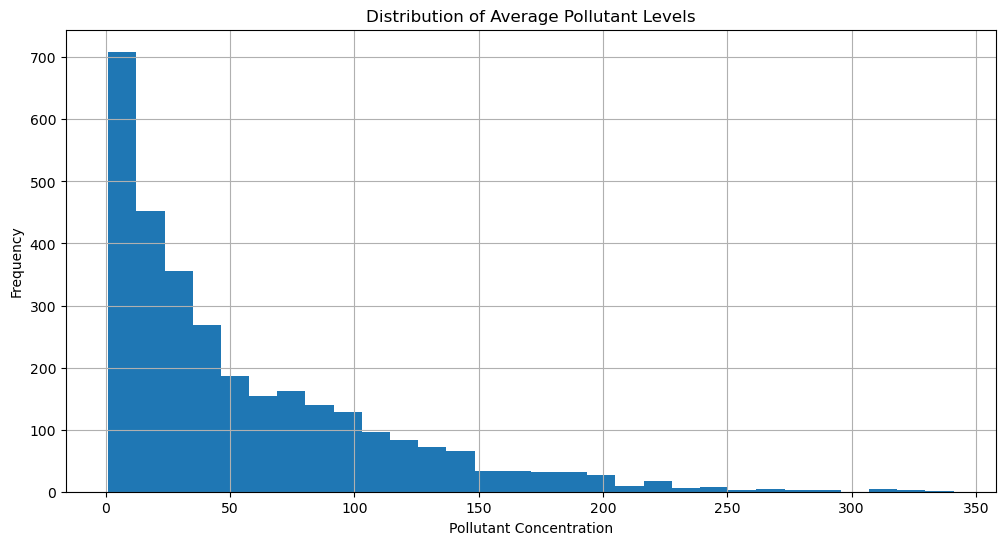

In [2]:
plt.figure(figsize=(12,6))
df['pollutant_avg'].hist(bins=30)
plt.title('Distribution of Average Pollutant Levels')
plt.xlabel('Pollutant Concentration')
plt.ylabel('Frequency')
plt.show()


## Top Polluted Cities

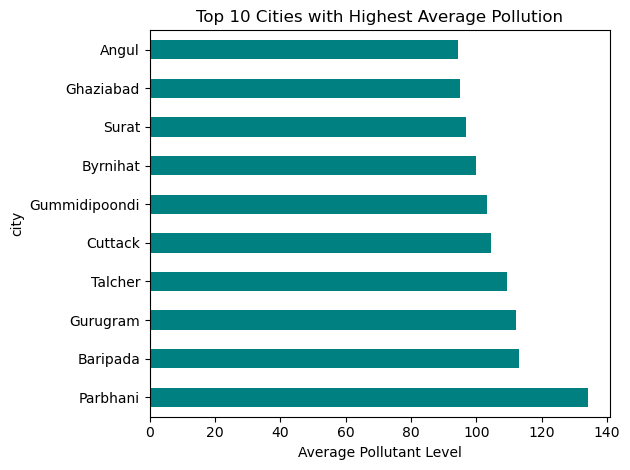

In [3]:
top_cities = df.groupby('city')['pollutant_avg'].mean().nlargest(10)
top_cities.plot(kind='barh', color='teal')
plt.title('Top 10 Cities with Highest Average Pollution')
plt.xlabel('Average Pollutant Level')
plt.tight_layout()


## Geographical Distribution

In [5]:
import folium

m = folium.Map(location=[20.5937, 78.9629], zoom_start=5)
for _, row in df.iterrows():
    folium.CircleMarker(
        location=[row['latitude'], row['longitude']],
        radius=row['pollutant_avg']/10,
        color='crimson',
        fill=True
    ).add_to(m)
m.save('pollution_map.html')


## State-wise Comparison

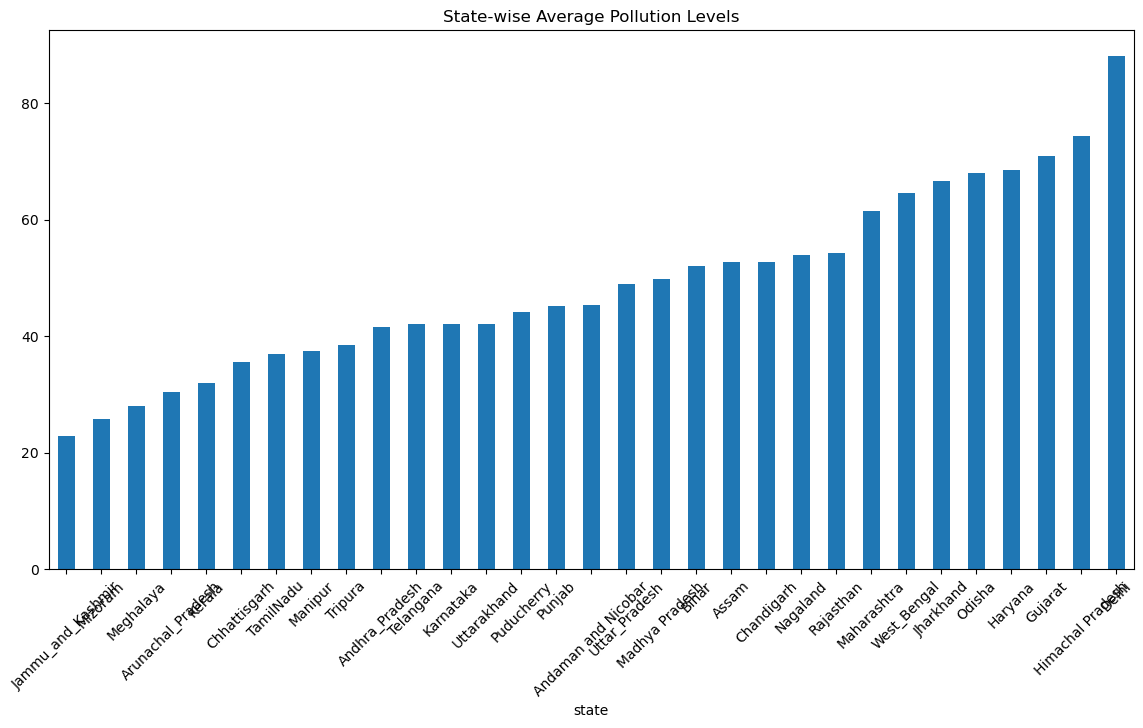

In [7]:
plt.figure(figsize=(14,7))
df.groupby('state')['pollutant_avg'].mean().sort_values().plot(kind='bar')
plt.title('State-wise Average Pollution Levels')
plt.xticks(rotation=45)
plt.show()


## Pollutant Correlation Analysis

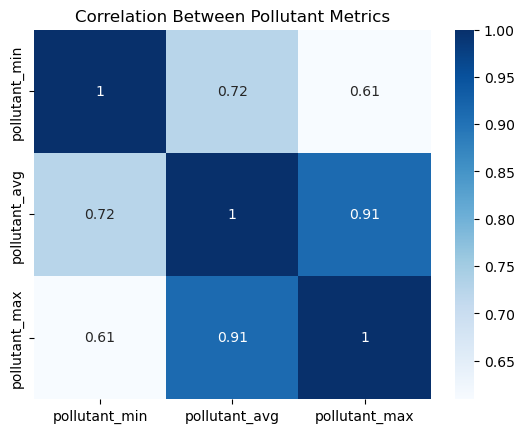

In [11]:
import seaborn as sns

sns.heatmap(df[['pollutant_min','pollutant_avg','pollutant_max']].corr(), 
            annot=True, cmap='Blues')
plt.title('Correlation Between Pollutant Metrics')
plt.show()


## Pollutant Variability Analysis

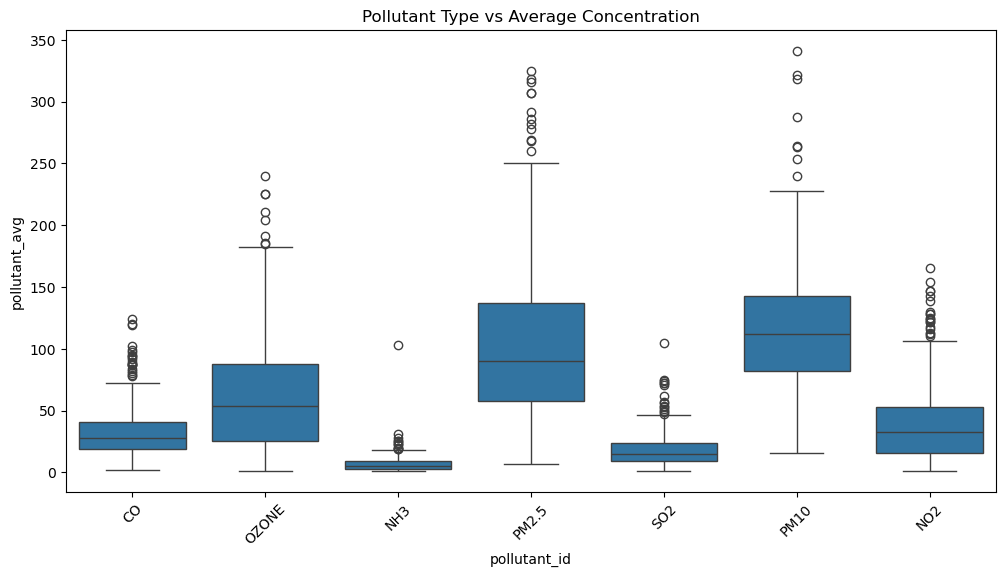

In [12]:
plt.figure(figsize=(12,6))
sns.boxplot(x='pollutant_id', y='pollutant_avg', data=df)
plt.title('Pollutant Type vs Average Concentration')
plt.xticks(rotation=45)
plt.show()
